<a href="https://colab.research.google.com/github/mehaksingh0210/internspark-task-1/blob/main/task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/customer-behavior-analysis")

print("Path to dataset files:", path)

100%|██████████| 9.94M/9.94M [00:01<00:00, 6.90MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/customer-behavior-analysis/versions/1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving customer-behaviour-analysis.csv to customer-behaviour-analysis (1).csv


# **Load Dataset**

In [5]:
df = pd.read_csv("customer-behaviour-analysis.csv")

# **View Dataset**

In [7]:
df.head()


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,03-05-2023 21:30,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,16-05-2021 13:57,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,13-07-2020 06:16,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,17-01-2023 13:14,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,01-05-2021 11:29,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [9]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


# **Data Cleaning**

In [10]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [6]:
df = df.dropna()

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print(df.shape)

(202618, 13)


# **Exploratory Data Analysis (EDA)**

# Customer Age Distribution

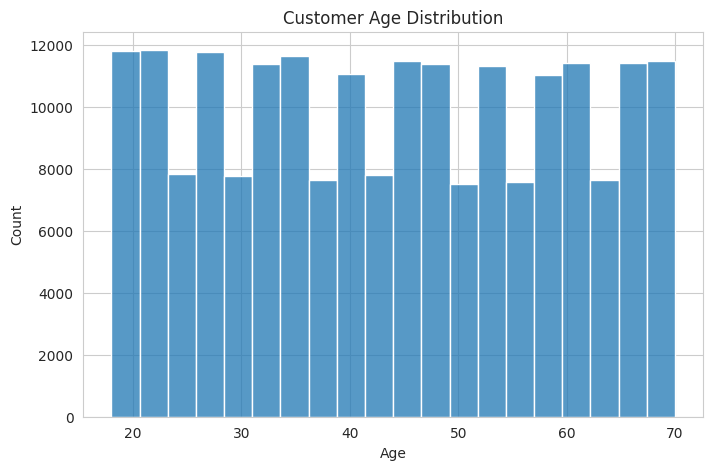

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

# Gender Distribution

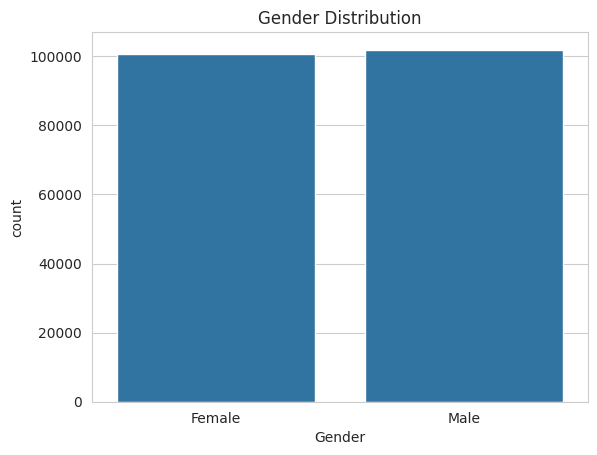

In [10]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

In [18]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


# Distribution of Purchase Amount

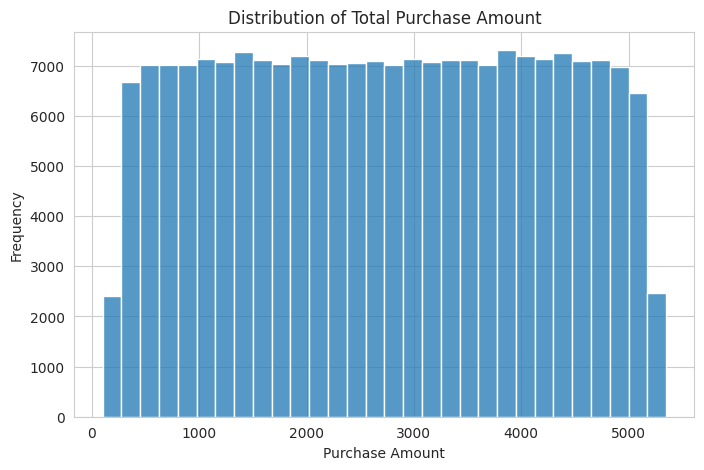

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Purchase Amount'], bins=30)
plt.title('Distribution of Total Purchase Amount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()

# Product Category Distribution

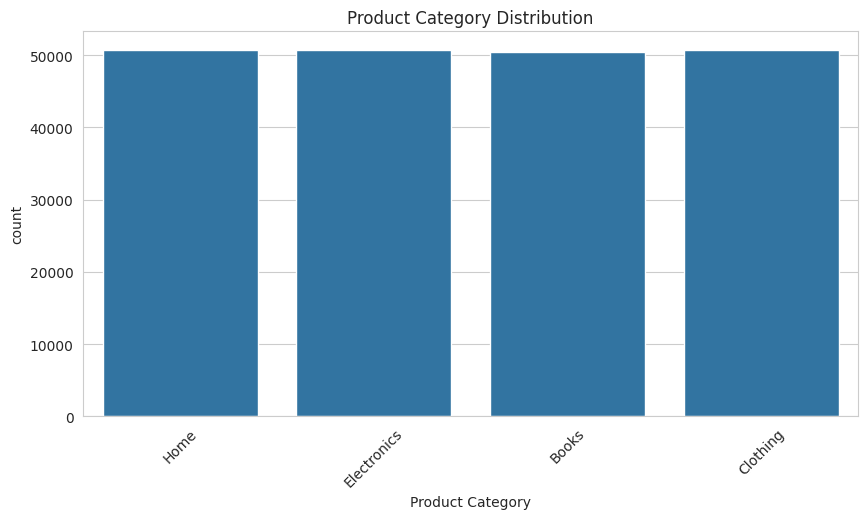

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(x='Product Category', data=df)
plt.xticks(rotation=45)
plt.title('Product Category Distribution')
plt.show()

**Churn Distribution**

In [22]:
df.head()
df['Churn'].value_counts()


,count
Churn,
0,161874
1,40744


# Payment Method Analysis

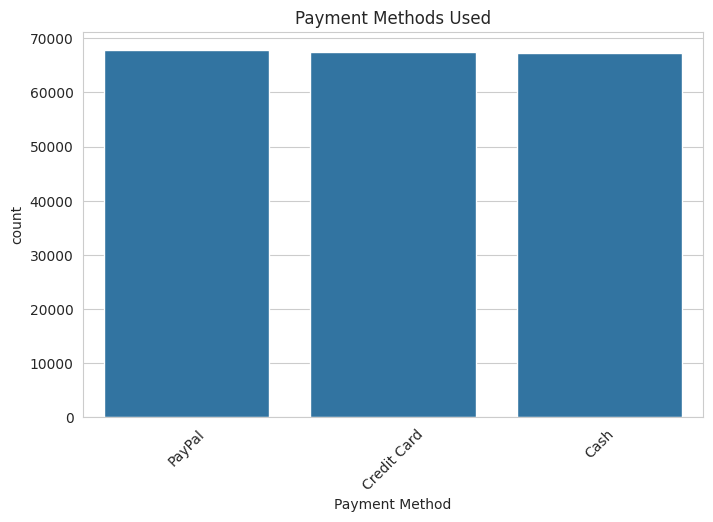

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Payment Method')
plt.xticks(rotation=45)
plt.title('Payment Methods Used')
plt.show()

# Returns Analysis

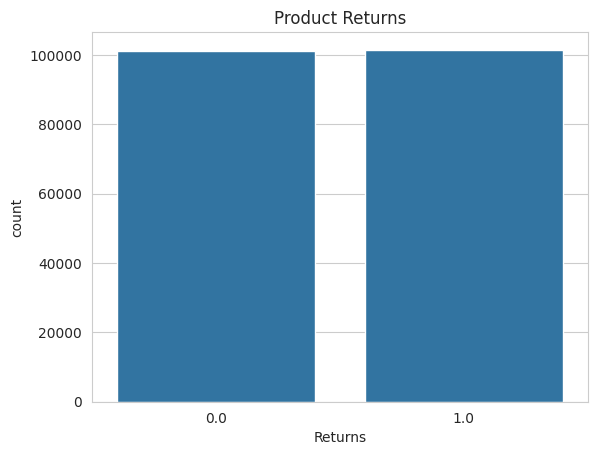

In [24]:
sns.countplot(data=df,x='Returns')
plt.title('Product Returns')
plt.show()

# **Feature Engineering**

**Average Order Value**

In [25]:
df['Average_Order_Value'] = (
    df['Total Purchase Amount'] /
    df['Quantity']
)

**Purchase Month**

In [27]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], dayfirst=True)

df['Purchase_Month'] = df['Purchase Date'].dt.month

**Purchase Year**

In [28]:
df['Purchase_Year'] = df['Purchase Date'].dt.year

# **Customer Segmentation**

# Customer Summary

In [29]:
customer_df = df.groupby('Customer ID').agg({
    'Total Purchase Amount':'sum',
    'Quantity':'sum',
    'Age':'first'
}).reset_index()

customer_df.head()

,Customer ID,Total Purchase Amount,Quantity,Age
0,1,5148,5,67
1,2,16481,18,42
2,3,4687,3,31
3,4,7826,19,37
4,5,7681,8,24


# Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

X = customer_df[
    ['Total Purchase Amount',
     'Quantity',
     'Age']
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method

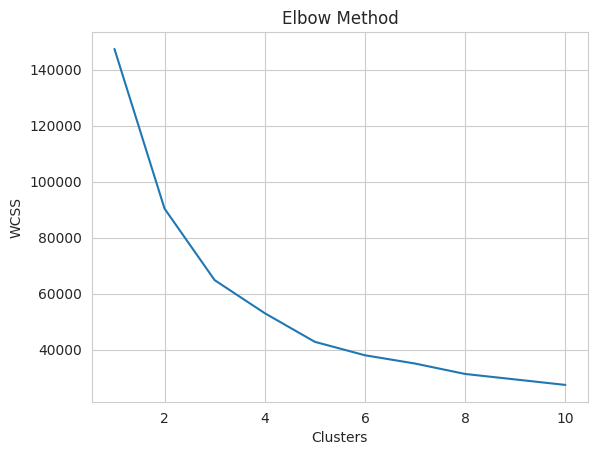

In [31]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Apply KMeans

In [32]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

customer_df['Cluster'] = (
    kmeans.fit_predict(X_scaled)
)

# Cluster Distribution

In [33]:
customer_df['Cluster'].value_counts()

,count
Cluster,
2,12024
0,10984
3,10540
4,10355
1,5243


# **Purchase Pattern Analysis**

# Top Categories

In [34]:
df.groupby(
    'Product Category'
)['Total Purchase Amount'].sum()\
.sort_values(ascending=False)

,Total Purchase Amount
Product Category,
Home,138906211
Clothing,138363540
Electronics,137884886
Books,137145086


# Payment Preferences

In [35]:
df.groupby(
    'Payment Method'
)['Total Purchase Amount'].sum()\
.sort_values(ascending=False)

,Total Purchase Amount
Payment Method,
Credit Card,184799917
PayPal,184585493
Cash,182914313


# Monthly Sales Trend

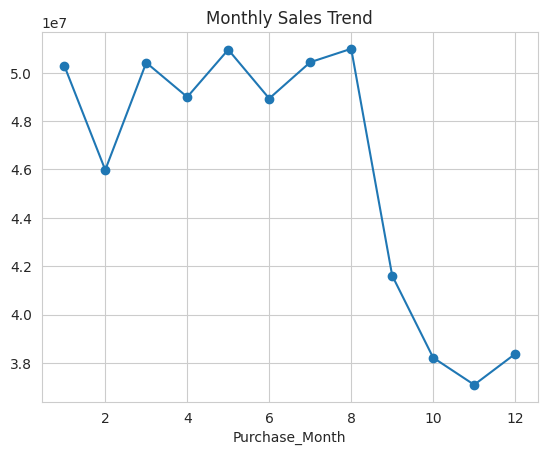

In [36]:
monthly_sales = df.groupby(
    'Purchase_Month'
)['Total Purchase Amount'].sum()

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.show()

# **Churn Analysis**

# Churn by Gender

In [37]:
pd.crosstab(
    df['Gender'],
    df['Churn']
)

Churn,0,1
Gender,,
Female,80339,20360
Male,81535,20384


# Churn Visualization

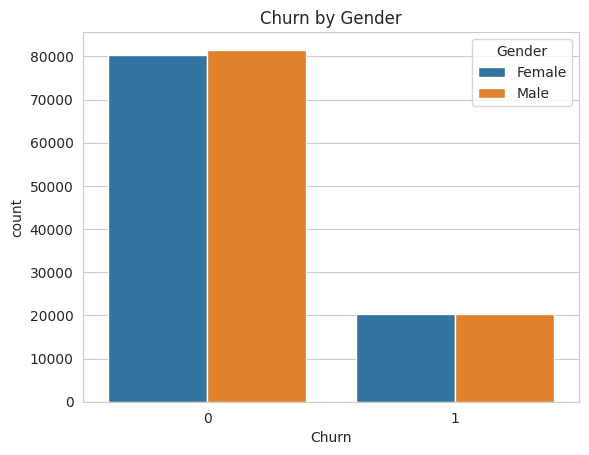

In [38]:
sns.countplot(
    x='Churn',
    hue='Gender',
    data=df
)

plt.title(
    'Churn by Gender'
)

plt.show()

# Churn by Product Category

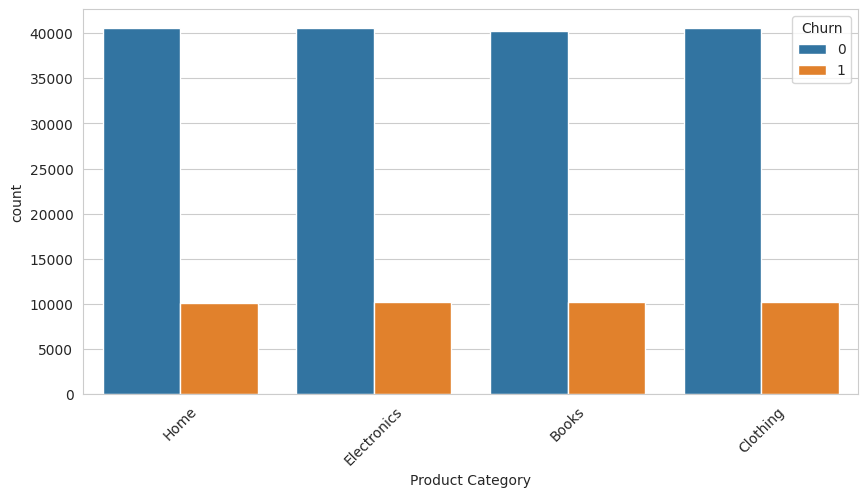

In [39]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Product Category',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)

plt.show()

# **Data Cleaning Results**

In [40]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


In [41]:
df.duplicated().sum()

np.int64(0)

# **Customer Segmentation Results**

In [42]:
customer_df['Cluster'].value_counts()

,count
Cluster,
2,12024
0,10984
3,10540
4,10355
1,5243


# **Cluster Summary**

In [43]:
cluster_summary = customer_df.groupby('Cluster').agg({
    'Total Purchase Amount':'mean',
    'Quantity':'mean',
    'Age':'mean'
}).round(2)

cluster_summary

,Total Purchase Amount,Quantity,Age
Cluster,,,
0,13475.17,14.35,57.41
1,22228.84,24.02,47.19
2,6553.22,7.52,30.40
3,6184.40,6.79,56.98
4,13883.45,15.83,29.98


# **Customer Segments Scatter Plot**

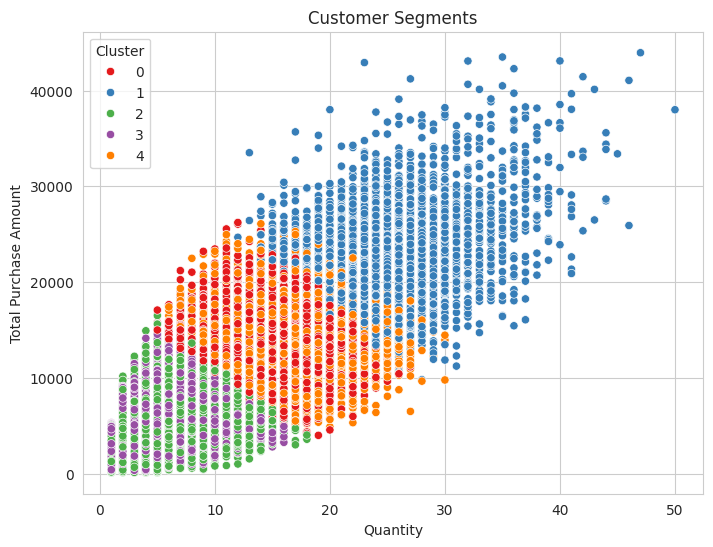

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x='Quantity',
    y='Total Purchase Amount',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments')
plt.show()